# Opt1: built directly on baseline

This version keeps the **baseline structure and pandas-based logic**, and only applies **Python-level optimizations** such as:

- caching the eval context once in `__init__`
- using local variable bindings inside hot loops
- reducing repeated attribute/global lookups
- precompiling factor expressions before evaluation

It does **not** replace the baseline implementation with new pandas/vectorized logic.


In [1]:
import os
import re
import json
import ast
import time
import warnings
import pickle

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm


In [2]:
# Initialize timing dictionary to collect execution times
timing = {}

## Part 1: Data Loading

In [3]:
def get_tickers(n_stocks):
    df = pd.read_csv("../data/sp500_tickers.csv")
    tickers = df["ticker"].tolist()
    return tickers[:n_stocks]

def load_sp500_data(start, end, n_stocks, cache_path="../data/sp500_cache.pkl"):
    if os.path.exists(cache_path):
        print("Cache found, loading from disk...")
        with open(cache_path, "rb") as f:
            data = pickle.load(f)
        print(f"Loaded: {data['close'].shape[0]} days x {data['close'].shape[1]} stocks")
        return data
 
    import yfinance as yf
    tickers = get_tickers(n_stocks)
    # --- Download price data from Yahoo Finance ---
    print(f"Downloading data from {start} to {end} ...")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=True)
 
    # --- Extract each field into its own DataFrame ---
    close  = raw["Close"].ffill().bfill()
    open_  = raw["Open"].ffill().bfill()
    high   = raw["High"].ffill().bfill()
    low    = raw["Low"].ffill().bfill()
    volume = raw["Volume"].ffill().bfill()
 
    # Drop stocks that are missing more than 10% of data
    min_rows = int(len(close) * 0.9)
    close = close.dropna(thresh=min_rows, axis=1)
 
    # Keep only the stocks that survived the filter
    valid = close.columns
    open_, high, low, volume = open_[valid], high[valid], low[valid], volume[valid]
 
    # --- Derive extra fields needed for factor calculation ---
    vwap    = (high + low + close) / 3          # typical price, proxy for VWAP
    returns = close.pct_change().fillna(0)      # daily return
    adv20   = volume.rolling(20).mean().bfill() # 20-day average daily volume
 
    print(f"Done: {close.shape[0]} days x {close.shape[1]} stocks")
 
    data = {
        "open": open_, "high": high, "low": low,
        "close": close, "volume": volume,
        "vwap": vwap, "returns": returns, "adv20": adv20,
    }
 
    # --- Save to cache ---
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    print(f"Saved to {cache_path}")
 
    return data

In [4]:
data = load_sp500_data(
    start    = "2023-01-01",
    end      = "2026-01-01",
    n_stocks = 500,
)
print(data["close"].head(3))

Cache found, loading from disk...
Loaded: 752 days x 483 stocks
Ticker               A    AAL        AAPL        ABBV       ABNB         ABT  \
Date                                                                           
2023-01-03  146.749939  12.74  123.096016  144.322632  84.900002  102.849213   
2023-01-04  148.344147  13.59  124.365662  145.486938  88.720001  104.379097   
2023-01-05  148.774521  13.99  123.046822  145.309204  87.709999  103.994286   

Ticker           ACGL         ACN        ADBE         ADI  ...         WTW  \
Date                                                       ...               
2023-01-03  59.393120  258.138916  336.920013  153.730545  ...  235.955490   
2023-01-04  59.687901  257.260101  341.410004  157.004852  ...  237.216171   
2023-01-05  59.849552  251.185394  328.440002  151.118698  ...  237.168060   

Ticker             WY       WYNN        XEL        XOM         XYL  \
Date                                                                 
2023

## Part 2: LLM factors generation

In [5]:
OPERATORS = """
Time-series operators (look back over past d days for each stock):
  ts_mean(x, d)     — rolling mean over d days
  ts_std(x, d)      — rolling standard deviation over d days
  ts_corr(x, y, d)  — rolling correlation between x and y over d days
  ts_delta(x, d)    — difference: today's value minus the value d days ago
  ts_max(x, d)      — rolling maximum over d days
  ts_min(x, d)      — rolling minimum over d days
 
Cross-sectional operators (compare across all stocks on the same day):
  rank(x)           — rank each stock from 0 to 1 (percentile)
  zscore(x)         — standardize: subtract mean, divide by std
 
Math operators:
  sign(x)           — returns +1, -1, or 0
  log(x)            — natural log
  abs(x)            — absolute value
  power(x, n)       — x to the power of n
 
Arithmetic: +  -  *  /
"""
 
DATA_FIELDS = """
Available data fields (each is a matrix: rows = dates, columns = stocks):
  open    — opening price
  high    — daily high price
  low     — daily low price
  close   — closing price
  volume  — trading volume
  vwap    — volume-weighted average price
  returns — daily return: (today - yesterday) / yesterday
  adv20   — 20-day average daily volume
"""
 
# Few-shot examples: show Claude what a good factor looks like
EXAMPLES = [
    {"factor": "rank(ts_corr(close, volume, 10))",
     "description": "10-day price-volume correlation rank — captures divergence signals"},
    {"factor": "ts_delta(close, 5) / ts_std(close, 20)",
     "description": "5-day momentum divided by 20-day volatility — momentum signal-to-noise ratio"},
    {"factor": "rank(close / ts_mean(close, 20))",
     "description": "Price deviation from 20-day moving average — mean reversion signal"},
    {"factor": "sign(ts_mean(volume, 10) - volume)",
     "description": "Positive when today's volume is below its 10-day average — shrinking volume signal"},
    {"factor": "rank(volume / adv20)",
     "description": "Today's volume relative to 20-day average — unusual activity signal"},
]
 
SYSTEM_PROMPT = f"""You are a quantitative researcher designing Alpha factors for stock markets.
 
Available operators:
{OPERATORS}
 
Available data fields:
{DATA_FIELDS}
 
Rules:
- Output a JSON array only, no extra text
- Each item must have "factor" (the expression) and "description" (the economic intuition)
- Only use the operators and fields listed above
"""
 

In [ ]:
import anthropic
import time
import json
import re
ANTHROPIC_API_KEY = "Your_API_Key_Here"
client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

In [7]:
def generate_factors(n_factors, theme=None):
    examples_str = "\n".join(
        f'  {{"factor": "{e["factor"]}", "description": "{e["description"]}"}}' 
        for e in EXAMPLES
    )
    theme_str = f"\nFocus on the theme: {theme}." if theme else ""

    user_msg = f"""Here are some known Alpha factor examples for reference:
[
{examples_str}
]
{theme_str}
Generate {n_factors} new, diverse Alpha factors. Output JSON array only."""

    try:
        response = client.messages.create(
            model="claude-opus-4-6",
            max_tokens=8096,
            thinking={"type": "adaptive"},
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": user_msg}]
        )
        raw = next(b.text for b in response.content if b.type == "text").strip()
        raw = re.sub(r"```(?:json)?|```", "", raw).strip()
        return json.loads(raw)
    except Exception as e:
        print(f"  Generation failed: {e}")
        return []


def validate_factor(expr):
    ALLOWED_OPERATORS = {
        "ts_mean", "ts_std", "ts_corr", "ts_delta", "ts_max", "ts_min",
        "rank", "zscore", "sign", "log", "abs", "power"
    }
    ALLOWED_FIELDS = {
        "open", "high", "low", "close", "volume", "vwap", "returns", "adv20"
    }

    try:
        tree = ast.parse(expr, mode="eval")
    except SyntaxError as e:
        return False, f"Syntax error: {e}"

    errors = []

    class Checker(ast.NodeVisitor):
        def visit_Call(self, node):
            if isinstance(node.func, ast.Name):
                if node.func.id not in ALLOWED_OPERATORS:
                    errors.append(f"Unknown operator: {node.func.id}")
            self.generic_visit(node)

        def visit_Name(self, node):
            if node.id not in ALLOWED_FIELDS and node.id not in ALLOWED_OPERATORS:
                errors.append(f"Unknown field: {node.id}")

        def visit_Attribute(self, node):
            errors.append("Attribute access not allowed")

    Checker().visit(tree)

    if errors:
        return False, "; ".join(errors)
    return True, ""


def get_factors(n_factors=20, themes=None, cache_path="../results/evaluation/factors.json"):

    # Load existing cache if present
    existing = []
    if os.path.exists(cache_path):
        with open(cache_path, "r") as f:
            existing = json.load(f)
        if len(existing) >= n_factors:
            print(f"Loading {len(existing)} factors from {cache_path}")
            return existing
        print(f"Found {len(existing)} cached factors, generating {n_factors - len(existing)} more via Claude...")

    if themes is None:
        themes = ["momentum", "mean reversion", "volume-price relationship", "volatility"]

    needed      = n_factors - len(existing)
    all_factors = list(existing)
    seen        = {f["factor"] for f in existing}
    batch_size  = max(5, needed // len(themes))

    for theme in themes:
        print(f"Generating factors — theme: {theme}")
        batch = generate_factors(batch_size, theme=theme)
        for f in batch:
            expr = f.get("factor", "").strip()
            if not expr or expr in seen:
                continue
            seen.add(expr)
            ok, err = validate_factor(expr)
            if ok:
                all_factors.append(f)
            else:
                print(f"  Rejected: {expr} — {err}")
        time.sleep(0.5)

    # Save to file so we don't need to call the API again
    with open(cache_path, "w") as f:
        json.dump(all_factors, f, indent=2)
    print(f"Saved {len(all_factors)} factors to {cache_path}")

    return all_factors


factors = get_factors(n_factors=200)
print(f"\n{len(factors)} factors ready:")
for i, f in enumerate(factors, 1):
    print(f"  {i}. {f['factor']}")
    print(f"     → {f['description']}")


Loading 216 factors from ../results/evaluation/factors.json

216 factors ready:
  1. rank(ts_mean(close, 5) - ts_mean(close, 20))
     → Rank of the difference between 5-day and 20-day closing price moving averages — captures short-term vs long-term price trend momentum.
  2. rank(ts_mean(returns, 20) / ts_std(returns, 20))
     → Rank of 20-day average daily return divided by 20-day standard deviation of returns — captures volatility-adjusted momentum (Sharpe-ratio like).
  3. rank(close - ts_min(low, 20))
     → Rank of today's closing price relative to the 20-day minimum low price — identifies stocks consistently closing significantly above their recent lows, indicating upward momentum.
  4. rank(ts_delta(vwap, 10) * (volume / adv20))
     → Rank of 10-day VWAP change multiplied by today's volume relative to its 20-day average volume — combines VWAP momentum with volume confirmation.
  5. rank(ts_mean(close - open, 5))
     → Rank of the 5-day average of (closing price - opening pri

## Part 3: Backtesting framework (Opt1: Python-level optimizations only)

In [8]:
class Opt1Backtester:

    def __init__(self, data):
        self.data = data
        self.ctx = self._build_context()

    def _build_context(self):
        d = self.data
        return {
            "open":    d["open"],
            "high":    d["high"],
            "low":     d["low"],
            "close":   d["close"],
            "volume":  d["volume"],
            "vwap":    d["vwap"],
            "returns": d["returns"],
            "adv20":   d["adv20"],
            "ts_mean":  self.ts_mean,
            "ts_std":   self.ts_std,
            "ts_delta": self.ts_delta,
            "ts_max":   self.ts_max,
            "ts_min":   self.ts_min,
            "ts_corr":  self.ts_corr,
            "rank":     self.rank,
            "zscore":   self.zscore,
            "sign":     self.sign,
            "log":      self.log,
            "abs":      lambda x: x.abs(),
            "power":    lambda x, n: x ** n,
        }

    def _empty_like(self, x):
        return pd.DataFrame(np.nan, index=x.index, columns=x.columns)

    # ── Time-series operators (same baseline logic, lighter Python overhead) ──

    def ts_mean(self, x, d):
        result = self._empty_like(x)
        result_iloc = result.iloc
        x_iloc = x.iloc
        for i in range(d - 1, len(x)):
            start = i - d + 1
            result_iloc[i] = x_iloc[start : i + 1].mean()
        return result

    def ts_std(self, x, d):
        result = self._empty_like(x)
        result_iloc = result.iloc
        x_iloc = x.iloc
        for i in range(d - 1, len(x)):
            start = i - d + 1
            result_iloc[i] = x_iloc[start : i + 1].std()
        return result

    def ts_delta(self, x, d):
        result = self._empty_like(x)
        result_iloc = result.iloc
        x_iloc = x.iloc
        for i in range(d, len(x)):
            result_iloc[i] = x_iloc[i] - x_iloc[i - d]
        return result

    def ts_max(self, x, d):
        result = self._empty_like(x)
        result_iloc = result.iloc
        x_iloc = x.iloc
        for i in range(d - 1, len(x)):
            start = i - d + 1
            result_iloc[i] = x_iloc[start : i + 1].max()
        return result

    def ts_min(self, x, d):
        result = self._empty_like(x)
        result_iloc = result.iloc
        x_iloc = x.iloc
        for i in range(d - 1, len(x)):
            start = i - d + 1
            result_iloc[i] = x_iloc[start : i + 1].min()
        return result

    def ts_corr(self, x, y, d):
        result = self._empty_like(x)
        result_at = result.at
        x_cols = x.columns
        x_idx = x.index

        for i in range(d - 1, len(x)):
            row_label = x_idx[i]
            start = i - d + 1
            stop = i + 1
            for col in x_cols:
                xs = x[col].iloc[start:stop]
                ys = y[col].iloc[start:stop]
                if xs.std() == 0 or ys.std() == 0:
                    result_at[row_label, col] = 0.0
                else:
                    result_at[row_label, col] = xs.corr(ys)
        return result

    # ── Cross-sectional operators (same baseline logic) ───────────────────────

    def rank(self, x):
        result = self._empty_like(x)
        result_loc = result.loc
        x_iloc = x.iloc
        x_idx = x.index
        for i in range(len(x)):
            row = x_iloc[i]
            valid = row.dropna()
            if len(valid) == 0:
                continue
            ranked = valid.rank(pct=True)
            result_loc[x_idx[i], ranked.index] = ranked
        return result

    def zscore(self, x):
        result = self._empty_like(x)
        result_iloc = result.iloc
        x_iloc = x.iloc
        for i in range(len(x)):
            row = x_iloc[i]
            mu = row.mean()
            sigma = row.std()
            if sigma == 0:
                result_iloc[i] = 0.0
            else:
                result_iloc[i] = (row - mu) / sigma
        return result

    # ── Math operators (same baseline logic) ──────────────────────────────────

    def sign(self, x):
        result = self._empty_like(x)
        result_iat = result.iat
        x_iat = x.iat
        n_rows, n_cols = x.shape
        for i in range(n_rows):
            for j in range(n_cols):
                val = x_iat[i, j]
                if val > 0:
                    result_iat[i, j] = 1.0
                elif val < 0:
                    result_iat[i, j] = -1.0
                else:
                    result_iat[i, j] = 0.0
        return result

    def log(self, x):
        result = self._empty_like(x)
        result_iat = result.iat
        x_iat = x.iat
        n_rows, n_cols = x.shape
        for i in range(n_rows):
            for j in range(n_cols):
                val = x_iat[i, j]
                result_iat[i, j] = np.log(max(val, 1e-9))
        return result

    # ── Factor computation ─────────────────────────────────────────────────────

    def compute_factor(self, expr, code_obj=None):
        local_eval = eval
        empty_builtins = {"__builtins__": {}}
        local_ctx = self.ctx
        if code_obj is None:
            code_obj = compile(expr, "<factor>", "eval")
        return local_eval(code_obj, empty_builtins, local_ctx)


def compute_all_factors(factors, data):
    bt = Opt1Backtester(data)
    results = {}

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        progress = tqdm(factors, desc="Computing factors", unit="factor")
        compiled = [(f["factor"], compile(f["factor"], "<factor>", "eval")) for f in factors]

        for expr, code_obj in compiled:
            progress.set_postfix_str(expr[:60], refresh=False)
            try:
                result = bt.compute_factor(expr, code_obj=code_obj)
                results[expr] = result
                progress.update(1)
            except Exception as e:
                progress.update(1)
                tqdm.write(f"Failed: {expr} -> {e}")

    print(f"Done: {len(results)}/{len(factors)} factors computed successfully")
    return results

In [10]:
with open("../results/evaluation/factors.json", "r") as f:
    factors = json.load(f)
print(f"Loaded {len(factors)} factors from ../results/evaluation/factors.json")

# Compute all factors
start = time.time()
factor_results = compute_all_factors(factors, data)
end = time.time()
timing['compute_all_factors'] = end - start
print(f"Time for compute_all_factors: {timing['compute_all_factors']:.2f} seconds")

# Print a sample of one factor's output
sample_expr   = list(factor_results.keys())[0]
sample_matrix = factor_results[sample_expr]
print(f"\nSample output for: {sample_expr}")
print(sample_matrix.iloc[:3, :5])
print(sample_matrix.iloc[25:28, :5])  # Skip the first 20 rows and inspect again

Loaded 216 factors from ../results/evaluation/factors.json


Computing factors:   0%|          | 0/216 [00:00<?, ?factor/s]

Done: 216/216 factors computed successfully
Time for compute_all_factors: 1814.62 seconds

Sample output for: rank(ts_mean(close, 5) - ts_mean(close, 20))
Ticker       A  AAL  AAPL  ABBV  ABNB
Date                                 
2023-01-03 NaN  NaN   NaN   NaN   NaN
2023-01-04 NaN  NaN   NaN   NaN   NaN
2023-01-05 NaN  NaN   NaN   NaN   NaN
Ticker             A       AAL      AAPL      ABBV      ABNB
Date                                                        
2023-02-08  0.207039  0.412008  0.908903  0.074534  0.915114
2023-02-09  0.202899  0.445135  0.913043  0.128364  0.910973
2023-02-10  0.182195  0.451346  0.919255  0.279503  0.902692


## Part 4: Performance evaluation

In [11]:
from scipy import stats
def compute_ic_series(factor, returns, forward_days=1):
    """
    For each day, compute the Spearman correlation between:
      - today's factor value (across all stocks)
      - tomorrow's actual return (across all stocks)
 
    A positive IC means the factor correctly predicted which stocks would go up.
    Returns a time series of daily IC values.
    """
    fwd_returns = returns.shift(-forward_days)
    ic_list = []
 
    for date in factor.index:
        f_row = factor.loc[date]
        r_row = fwd_returns.loc[date]
 
        valid = f_row.notna() & r_row.notna()
        if valid.sum() < 10:
            ic_list.append(np.nan)
            continue
 
        corr, _ = stats.spearmanr(f_row[valid], r_row[valid])
        ic_list.append(corr)
 
    return pd.Series(ic_list, index=factor.index)
 
 
def compute_long_short_returns(factor, returns, quantile=0.1, forward_days=1):
    """
    Build a long-short portfolio each day:
      - Long:  top quantile stocks by factor value (e.g. top 10%)
      - Short: bottom quantile stocks by factor value (e.g. bottom 10%)
      - Daily P&L = average long return - average short return
 
    Returns a time series of daily portfolio returns.
    """
    fwd_returns = returns.shift(-forward_days)
    port_returns = []
 
    for date in factor.index[:-forward_days]:
        f_row = factor.loc[date]
        r_row = fwd_returns.loc[date]
        valid = f_row.notna() & r_row.notna()
 
        if valid.sum() < 20:
            port_returns.append(np.nan)
            continue
 
        f_valid = f_row[valid]
        r_valid = r_row[valid]
        n = len(f_valid)
        k = max(1, int(n * quantile))
 
        ranked     = f_valid.rank()
        long_ret   = r_valid[ranked >= (n - k + 1)].mean()
        short_ret  = r_valid[ranked <= k].mean()
        port_returns.append(long_ret - short_ret)
 
    return pd.Series(port_returns, index=factor.index[:-forward_days])
 
 
def evaluate_factor(factor, returns, forward_days=1, quantile=0.1):
    """
    Compute all five metrics for a single factor.
    Returns a dict of scores.
    """
    # IC and ICIR
    ic = compute_ic_series(factor, returns, forward_days).dropna()
    ic_mean = ic.mean()
    ic_std  = ic.std()
    icir    = ic_mean / ic_std if ic_std > 0 else 0.0
 
    # Long-short portfolio
    ls_ret = compute_long_short_returns(factor, returns, quantile, forward_days).dropna()
 
    # Sharpe (annualized)
    sharpe = (ls_ret.mean() / ls_ret.std() * np.sqrt(252)) if ls_ret.std() > 0 else 0.0
 
    # Max Drawdown
    nav = (1 + ls_ret).cumprod()
    mdd = ((nav - nav.cummax()) / nav.cummax()).min()
 
    # Turnover: how much the stock selection changes each day
    turnover_list = []
    prev = None
    for date in factor.index:
        f_row = factor.loc[date]
        valid = f_row.notna()
        if valid.sum() < 20:
            continue
        f_valid = f_row[valid]
        n = len(f_valid)
        k = max(1, int(n * quantile))
        ranked = f_valid.rank()
        curr   = set(f_valid[ranked >= (n - k + 1)].index) | set(f_valid[ranked <= k].index)
        if prev is not None:
            changed = len(curr.symmetric_difference(prev))
            total   = len(curr) + len(prev)
            turnover_list.append(changed / total if total > 0 else 0)
        prev = curr
    turnover = np.mean(turnover_list) if turnover_list else np.nan
 
    return {
        "IC_mean": round(ic_mean, 4),
        "ICIR":    round(icir, 4),
        "Sharpe":  round(sharpe, 4),
        "MDD":     round(mdd, 4),
        "Turnover":round(turnover, 4),
    }
 
 
# ── Evaluate all factors and rank them ────────────────────────────────────────
 
def evaluate_all_factors(factor_results, returns):
    """
    Run evaluate_factor() for every factor.
    Returns a DataFrame sorted by composite score (best factor first).
    """
    rows = []
 
    for i, (expr, factor_df) in enumerate(factor_results.items(), 1):
        print(f"[{i}/{len(factor_results)}] Evaluating: {expr[:60]}")
        metrics         = evaluate_factor(factor_df, returns)
        metrics["factor"] = expr
        rows.append(metrics)
 
    df = pd.DataFrame(rows)
 
    # Composite score: normalize each metric to 0-1 then take weighted average
    def minmax(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else pd.Series(0.5, index=s.index)
 
    df["score"] = (
        minmax(df["ICIR"])         * 0.35 +
        minmax(df["Sharpe"])       * 0.30 +
        minmax(df["IC_mean"])      * 0.15 +
        minmax(-df["MDD"])         * 0.15 +  # closer to 0 is better, so negate
        minmax(-df["Turnover"])    * 0.05     # lower turnover is better, so negate
    ).round(4)
 
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    df.index = range(1, len(df) + 1)
    df.index.name = "rank"
 
    return df

In [12]:
returns = data["returns"]

# Load factors
with open("../results/evaluation/factors.json") as f:
    factors = json.load(f)

# Compute factor matrices (Part 3)
factor_results = compute_all_factors(factors, data)

# Evaluate and rank (Part 4)
start = time.time()
results = evaluate_all_factors(factor_results, returns)
end = time.time()
timing['evaluate_all_factors'] = end - start
print(f"Time for evaluate_all_factors: {timing['evaluate_all_factors']:.2f} seconds")

# Print results
print("\nFactor ranking:")
print(results[["factor", "IC_mean", "ICIR", "Sharpe", "MDD", "Turnover", "score"]].to_string())

# Save to CSV
results.to_csv("../results/evaluation/factor_evaluation.csv")
print("\nSaved to ../results/evaluation/factor_evaluation.csv")

Computing factors:   0%|          | 0/216 [00:00<?, ?factor/s]

Done: 216/216 factors computed successfully
[1/216] Evaluating: rank(ts_mean(close, 5) - ts_mean(close, 20))
[2/216] Evaluating: rank(ts_mean(returns, 20) / ts_std(returns, 20))
[3/216] Evaluating: rank(close - ts_min(low, 20))
[4/216] Evaluating: rank(ts_delta(vwap, 10) * (volume / adv20))
[5/216] Evaluating: rank(ts_mean(close - open, 5))
[6/216] Evaluating: rank((ts_mean(close, 20) - close) / ts_std(close, 20))
[7/216] Evaluating: rank(open / close)
[8/216] Evaluating: rank(ts_mean(returns, 20) - ts_mean(returns, 5))
[9/216] Evaluating: rank((ts_max(high, 20) - close) / (ts_max(high, 20) - ts_min
[10/216] Evaluating: rank(log(volume / adv20) * sign(ts_delta(close, 5)))


/var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_36686/1207720711.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.spearmanr(f_row[valid], r_row[valid])


[11/216] Evaluating: rank(ts_corr(returns, volume / adv20, 10))
[12/216] Evaluating: rank((close - vwap) * (volume / adv20))
[13/216] Evaluating: rank(ts_mean(volume, 5) / ts_std(close, 5))
[14/216] Evaluating: rank(ts_corr(ts_delta(close, 1), ts_delta(volume, 1), 20))
[15/216] Evaluating: rank(-ts_corr(ts_delta(close, 5), ts_mean(volume, 5) - volum
[16/216] Evaluating: rank(ts_std(returns, 5) / ts_std(returns, 20))
[17/216] Evaluating: rank(ts_std(close / ts_mean(close, 10), 20))
[18/216] Evaluating: rank((high - low) / ts_mean(high - low, 20))
[19/216] Evaluating: rank(ts_std(returns, 10) * (volume / adv20))
[20/216] Evaluating: rank(ts_std(ts_std(returns, 5), 20))
[21/216] Evaluating: ts_delta(close, 10) / ts_std(close, 10)
[22/216] Evaluating: rank(ts_delta(close, 20) / close)
[23/216] Evaluating: rank(close / ts_max(close, 60))
[24/216] Evaluating: rank(close - ts_mean(close, 5)) - rank(close - ts_mean(close
[25/216] Evaluating: ts_delta(close, 5) * rank(volume / adv20)
[26/216] E

## Part 5: PLotting results

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_score_ranking(results):
    fig, ax = plt.subplots(figsize=(12, 6))
 
    colors = ["blue" if s > 0.5 else "red" for s in results["score"]]
    labels = [f[:40] + "..." if len(f) > 40 else f for f in results["factor"]]
 
    ax.barh(range(len(results)), results["score"], color=colors)
    ax.set_yticks(range(len(results)))
    ax.set_yticklabels([f"#{i+1} {l}" for i, l in enumerate(labels)], fontsize=8)
    ax.axvline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel("Composite Score")
    ax.set_title("Factor Ranking by Composite Score")
    ax.invert_yaxis()
 
    plt.tight_layout()
    plt.savefig("../results/plots/plot1_ranking.png", dpi=150, bbox_inches="tight")
    print("Saved: ../results/plots/plot1_ranking.png")
    plt.show()
    plt.close()
 
 
# ── Plot 2: ICIR vs Sharpe scatter ────────────────────────────────────────────
 
def plot_icir_vs_sharpe(results):
    fig, ax = plt.subplots(figsize=(10, 7))
 
    scatter = ax.scatter(
        results["ICIR"],
        results["Sharpe"],
        c=results["score"],
        cmap="RdYlGn",
        s=100,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5,
    )
 
    # Label top 5
    for _, row in results.head(5).iterrows():
        label = row["factor"][:30] + "..."
        ax.annotate(label, xy=(row["ICIR"], row["Sharpe"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=7)
 
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("ICIR (signal stability)")
    ax.set_ylabel("Sharpe (risk-adjusted return)")
    ax.set_title("ICIR vs Sharpe — top-right is best")
    plt.colorbar(scatter, ax=ax, label="Composite Score")
 
    plt.tight_layout()
    plt.savefig("../results/plots/plot2_scatter.png", dpi=150, bbox_inches="tight")
    print("Saved: ../results/plots/plot2_scatter.png")
    plt.show()
    plt.close()
 
 
# ── Plot 3: IC series + NAV curve for the top factor ─────────────────────────
 
def plot_top_factor_detail(results, factor_results, returns):
    top_expr  = results.iloc[0]["factor"]
    top_score = results.iloc[0]["score"]
    factor_df = factor_results[top_expr]
 
    ic     = compute_ic_series(factor_df, returns).dropna()
    ls_ret = compute_long_short_returns(factor_df, returns).dropna()
    nav    = (1 + ls_ret).cumprod()
 
    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)
 
    # Left: IC time series
    ax1 = fig.add_subplot(gs[0, 0])
    ic.plot(ax=ax1, color="#90CAF9", alpha=0.4, linewidth=0.8, label="Daily IC")
    ic.rolling(20).mean().plot(ax=ax1, color="#1565C0", linewidth=2, label="20D Rolling Mean")
    ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax1.set_title("IC Time Series — Top Factor", fontsize=10)
    ax1.set_ylabel("IC")
    ax1.legend(fontsize=8)
 
    # Right: NAV curve
    ax2 = fig.add_subplot(gs[0, 1])
    nav.plot(ax=ax2, color="#2E7D32", linewidth=2)
    ax2.fill_between(nav.index, 1, nav.values, alpha=0.1, color="#2E7D32")
    ax2.axhline(1, color="black", linewidth=0.8, linestyle="--")
    ax2.set_title("Long-Short Portfolio NAV", fontsize=10)
    ax2.set_ylabel("Net Asset Value")
 
    label = top_expr[:60] + ("..." if len(top_expr) > 60 else "")
    fig.suptitle(f"#{1}  {label}  (score={top_score})", fontsize=10, y=1.02)
 
    plt.tight_layout()
    plt.savefig("../results/plots/plot3_top_factor.png", dpi=150, bbox_inches="tight")
    print("Saved: ../results/plots/plot3_top_factor.png")
    plt.show()
    plt.close()

Computing factors:   0%|          | 0/216 [00:00<?, ?factor/s]

Done: 216/216 factors computed successfully
[1/216] Evaluating: rank(ts_mean(close, 5) - ts_mean(close, 20))
[2/216] Evaluating: rank(ts_mean(returns, 20) / ts_std(returns, 20))
[3/216] Evaluating: rank(close - ts_min(low, 20))
[4/216] Evaluating: rank(ts_delta(vwap, 10) * (volume / adv20))
[5/216] Evaluating: rank(ts_mean(close - open, 5))
[6/216] Evaluating: rank((ts_mean(close, 20) - close) / ts_std(close, 20))
[7/216] Evaluating: rank(open / close)
[8/216] Evaluating: rank(ts_mean(returns, 20) - ts_mean(returns, 5))
[9/216] Evaluating: rank((ts_max(high, 20) - close) / (ts_max(high, 20) - ts_min
[10/216] Evaluating: rank(log(volume / adv20) * sign(ts_delta(close, 5)))


/var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_36686/1207720711.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.spearmanr(f_row[valid], r_row[valid])


[11/216] Evaluating: rank(ts_corr(returns, volume / adv20, 10))
[12/216] Evaluating: rank((close - vwap) * (volume / adv20))
[13/216] Evaluating: rank(ts_mean(volume, 5) / ts_std(close, 5))
[14/216] Evaluating: rank(ts_corr(ts_delta(close, 1), ts_delta(volume, 1), 20))
[15/216] Evaluating: rank(-ts_corr(ts_delta(close, 5), ts_mean(volume, 5) - volum
[16/216] Evaluating: rank(ts_std(returns, 5) / ts_std(returns, 20))
[17/216] Evaluating: rank(ts_std(close / ts_mean(close, 10), 20))
[18/216] Evaluating: rank((high - low) / ts_mean(high - low, 20))
[19/216] Evaluating: rank(ts_std(returns, 10) * (volume / adv20))
[20/216] Evaluating: rank(ts_std(ts_std(returns, 5), 20))
[21/216] Evaluating: ts_delta(close, 10) / ts_std(close, 10)
[22/216] Evaluating: rank(ts_delta(close, 20) / close)
[23/216] Evaluating: rank(close / ts_max(close, 60))
[24/216] Evaluating: rank(close - ts_mean(close, 5)) - rank(close - ts_mean(close
[25/216] Evaluating: ts_delta(close, 5) * rank(volume / adv20)
[26/216] E

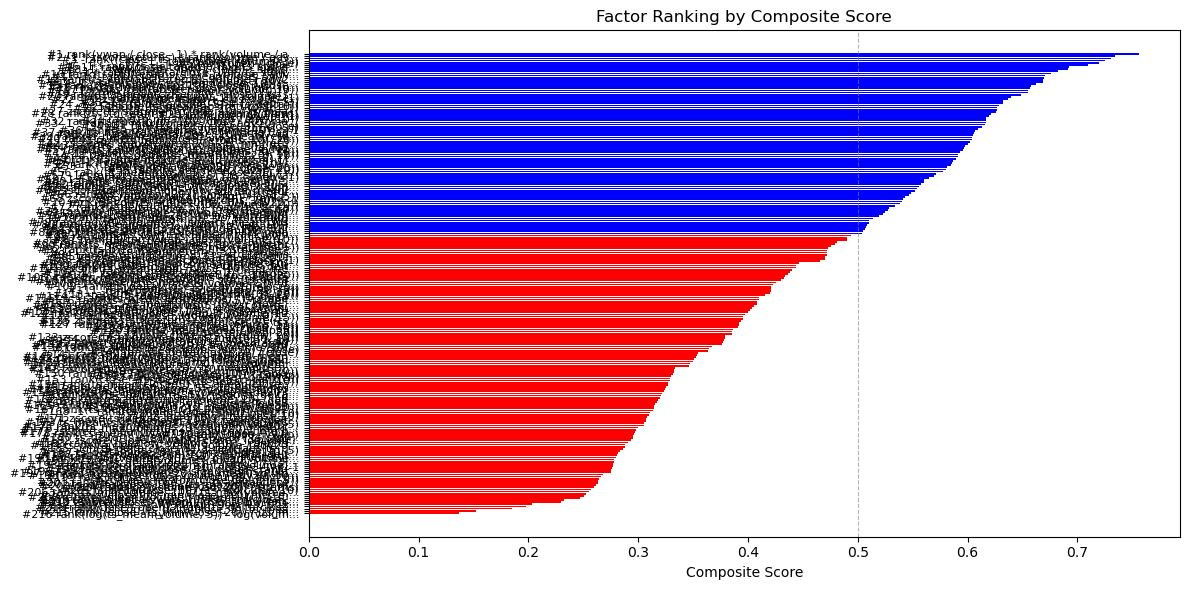

Saved: ../results/plots/plot2_scatter.png


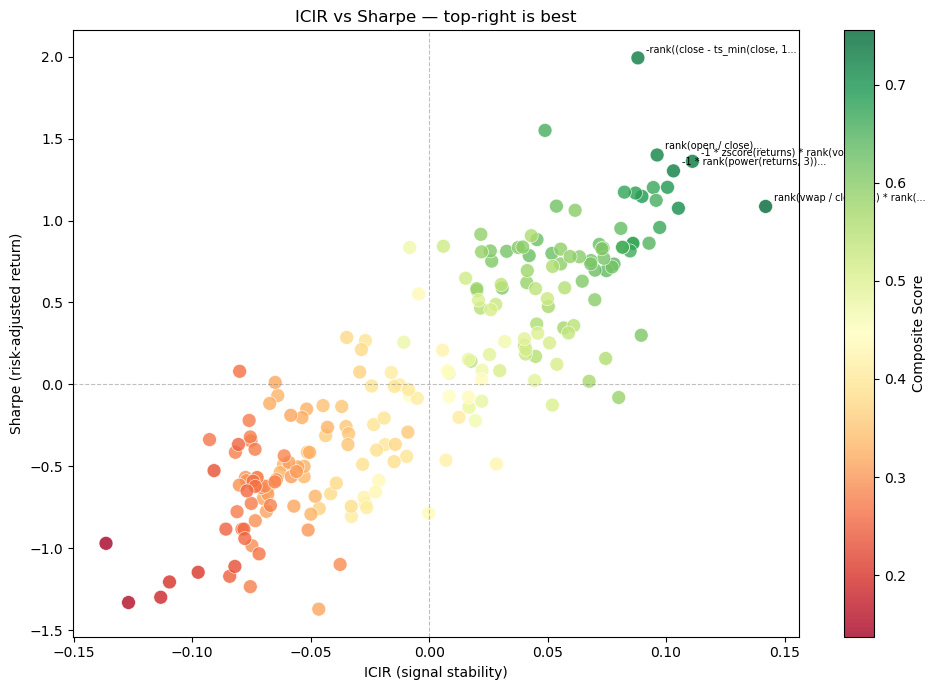

/var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_36686/1272580343.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../results/plots/plot3_top_factor.png


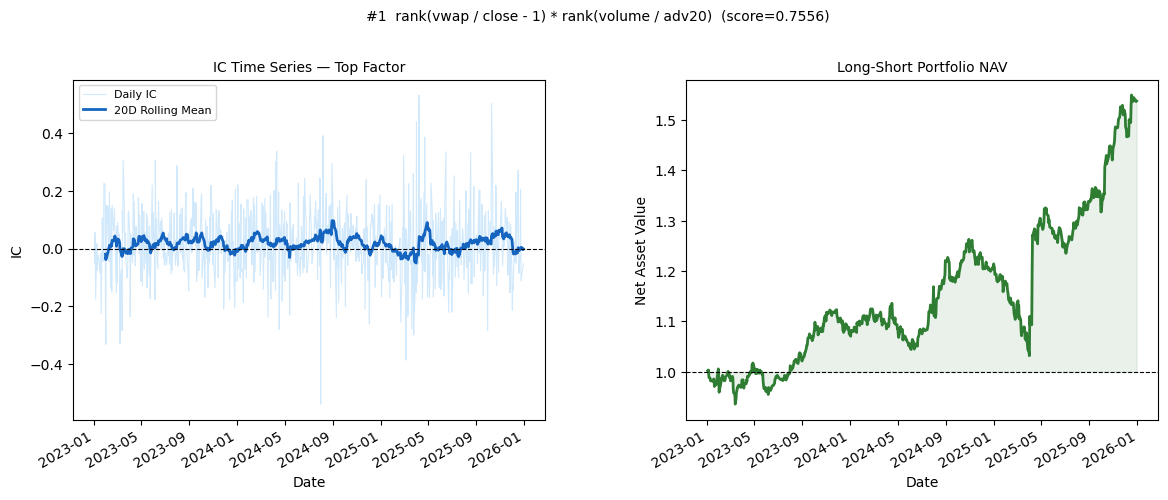

In [14]:
factor_results = compute_all_factors(factors, data)
results        = evaluate_all_factors(factor_results, returns)

plot_score_ranking(results)
plot_icir_vs_sharpe(results)
plot_top_factor_detail(results, factor_results, returns)

## Timing Infrastructure

In [15]:
# Save timing data to CSV
timing_df = pd.DataFrame(list(timing.items()), columns=['function', 'time'])
timing_df.to_csv("../results/timing/opt1_timing.csv", index=False)
print("Timing data saved to ../results/timing/opt1_timing.csv")
print(timing_df)

Timing data saved to ../results/timing/opt1_timing.csv
               function         time
0   compute_all_factors  1814.619027
1  evaluate_all_factors   158.362157


## Part X: line_profiler Performance Analysis (Opt1)

Make sure it is installed first: `pip install line_profiler`

Recommended to run in Jupyter first:

- `%load_ext line_profiler`
- Then run the two `%lprun` cells below


In [16]:
# If this is your first use, install in terminal first:
# pip install line_profiler

%load_ext line_profiler


In [17]:
# 1) Check overall bottleneck: compute_all_factors
%lprun -f compute_all_factors compute_all_factors(factors, data)


Computing factors:   0%|          | 0/216 [00:00<?, ?factor/s]

Done: 216/216 factors computed successfully


Timer unit: 1e-09 s

Total time: 20262.1 s
File: /var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_36686/1543704818.py
Function: compute_all_factors at line 170

Line #      Hits         Time  Per Hit   % Time  Line Contents
   170                                           def compute_all_factors(factors, data):
   171         1      18000.0  18000.0      0.0      bt = Opt1Backtester(data)
   172         1          0.0      0.0      0.0      results = {}
   173                                           
   174         2      28000.0  14000.0      0.0      with warnings.catch_warnings():
   175         1      12000.0  12000.0      0.0          warnings.simplefilter("ignore")
   176         1    9472000.0 9.47e+06      0.0          progress = tqdm(factors, desc="Computing factors", unit="factor")
   177         1    1696000.0  1.7e+06      0.0          compiled = [(f["factor"], compile(f["factor"], "<factor>", "eval")) for f in factors]
   178                                    

In [18]:
# 2) Check key operators in class internals (rolling corr is often a hotspot)
bt_profile = Opt1Backtester(data)
%lprun -f bt_profile.ts_corr -f bt_profile.compute_factor bt_profile.compute_factor(factors[0]['factor'])


Timer unit: 1e-09 s

Total time: 0 s
File: /var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_36686/1543704818.py
Function: Opt1Backtester.ts_corr at line 81

Line #      Hits         Time  Per Hit   % Time  Line Contents
    81                                               def ts_corr(self, x, y, d):
    82                                                   result = self._empty_like(x)
    83                                                   result_at = result.at
    84                                                   x_cols = x.columns
    85                                                   x_idx = x.index
    86                                           
    87                                                   for i in range(d - 1, len(x)):
    88                                                       row_label = x_idx[i]
    89                                                       start = i - d + 1
    90                                                       stop = i + 1
  